# M1 · HITL vehicle part segmentation

**Manual experiment workbook · SegFormer-B2 default · editable alternatives · unexecuted template.**

SegFormer-B2 is the model architecture; HITL is the dataset. Run cells in order, inspect the prepared data, then start training when ready. All weights, logs and evaluation exports go under `artifacts/`; original downloads remain under `data/raw/`.

This notebook fine-tunes a separate **22-class model: 21 HITL parts plus background**. It predicts a part category at each pixel. HITL carries no left/right labels, so downstream side identity remains `unknown`; damage, repair necessity and operation are separate tasks. The reviewed source label `License-plate` maps to `licence-plate` in the converter.

This notebook supports offline model development. It neither installs a trained model into the application nor establishes a runtime acceptance result. The SegFormer-B2 choice follows the current user request and supersedes the older proposed B0 recipe for these experiments.


## Training plan and workflow

1. Acquire the two permitted HITL Supervisely exports, retain the original archives and source provenance, and extract them under `data/raw/`. The user supplied `data/raw/CarPartsAndCarDamages.zip` and its extracted `data/raw/CarPartsAndCarDamages/` directory on 2026-09-30. On another machine, copy these inputs or complete the acquisition instructions before conversion.
2. Inspect `meta.json` and actual annotations to identify the parts/damage tasks; historical folder names were swapped. Convert both tasks together, audit polygons and overlap, and freeze one split manifest over their image union.
3. Inspect **training/validation** mask overlays and rare-class support. Review near-duplicate candidates and group related views before training. Reserve assignment evaluation examples across both tasks with the same reservation file.
4. Start with SegFormer-B2, the explicit configuration below, and a one-epoch exploratory run if hardware capacity is uncertain. Give every run a distinct artifact directory. An exploratory run is not a final model result.
5. Fine-tune the pretrained encoder and new task head; select the best checkpoint and hyperparameters using validation foreground mIoU. Compare architectures on identical prepared data and splits, changing one factor at a time.
6. Freeze the chosen configuration, taxonomy, class inclusion policy and checkpoint. Enable final test evaluation only after selection is complete; inspect all class results and failure overlays without retuning on test.
7. Optionally export the frozen run as a registry candidate for the M1 worker, in the last code section. Serving it is a separate change to `configs/models/parts.yaml`.

The configuration cell offers three recipe presets, so each change can be measured separately on validation:

- `baseline` reproduces the first v1 run: encoder/head learning rates 6e-6/6e-5, a cosine schedule stepped once per epoch, 30 epochs, early-stopping patience 8, and only flip and brightness/contrast augmentation.
- `fixed` raises the learning rates to the standard SegFormer values of 6e-5/6e-4, adds a two-epoch linear warmup and a polynomial decay applied after every optimizer update, and trains up to 100 epochs with patience 15.
- `fixed_aug` (the default) is `fixed` plus random scale-and-crop, rotation and saturation augmentation.

All presets use batch size 2 with accumulation of 4 batches (effective batch 8) and AdamW. These are starting values, not measured optima. GPU seeds improve repeatability but do not guarantee bitwise equality across hardware.


## Environment and repository paths

Use a dedicated Python environment and select it as the Jupyter kernel. `requirements-training.txt` defines the training dependencies. On an NVIDIA machine, install the appropriate PyTorch/CUDA build for that machine first. On Apple Silicon, the native macOS PyTorch build can use Metal (`mps`). The optional installation cell is disabled by default and runs in the current kernel's Python only when explicitly enabled. Restart the kernel after installation, then rerun from the first cell.


In [1]:
from pathlib import Path
import sys
import json
import os

# Works when Jupyter starts in the repository root or a subdirectory such as notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "docs/specs/README.md").is_file()
             and (p / "pipelines").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the CLAIM-CMEV checkout, or set ROOT to its path.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# Set caches before importing transformers/torch; preserve any user overrides.
os.environ.setdefault("HF_HOME", str(ROOT / "artifacts/models/.cache/huggingface"))
os.environ.setdefault("TORCH_HOME", str(ROOT / "artifacts/models/.cache/torch"))
print("Repository:", ROOT)
print("Kernel Python:", sys.executable)


Repository: /Users/rodel/Projects/nus/CLAIM-CMEV
Kernel Python: /Users/rodel/Projects/nus/CLAIM-CMEV/venv/bin/python


In [2]:
INSTALL_DEPENDENCIES = False  # Set True only to install into this kernel's environment.
if INSTALL_DEPENDENCIES:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r",
                           str(ROOT / "requirements-training.txt")])
    print("Restart the kernel after installation, then rerun this notebook.")


In [3]:
from dataclasses import asdict
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from IPython.display import display

from pipelines.vision.hitl_data import prepare_hitl
from pipelines.vision.training import (
    TrainingConfig, train, evaluate_run, select_device, build_model, model_summary,
    plot_history, plot_confusion, show_predictions, show_targets, compare_runs,
)

DEVICE = "auto"  # auto -> CUDA, then Apple MPS, then CPU; or "cuda", "mps", "cpu".
print("PyTorch:", torch.__version__)
print("Selected device:", select_device(DEVICE))
print("CUDA available:", torch.cuda.is_available())
print("Apple MPS available:", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


PyTorch: 2.14.0
Selected device: mps
CUDA available: False
Apple MPS available: True


## Shared HITL preprocessing and leakage controls

The converter reads Supervisely `meta.json` and asserts the exact task vocabulary rather than trusting directory names. It rasterizes polygon exteriors and interior holes at source resolution. HITL annotators nest polygons: a door includes its window and mirror, a bumper its licence plate and grille, a dent its scratches. Same-class overlap is merged. When two polygons of different classes overlap and at least 80% of the smaller one lies inside the larger, the smaller polygon keeps the shared pixels. Other different-class overlaps, such as slivers at part seams or partially overlapping damage, are marked ignore ID 255. This `nested` policy follows the training specification's smaller-region-on-top proposal and is recorded in the manifest.

The first preparation, `data/processed/hitl/v1`, ignored every different-class overlap. It discarded most window, mirror and licence-plate labels (63-88% of their annotated pixels), so v1 and v2 results are not comparable. v1 remains available with `OVERLAP_POLICY = "ignore_all"`. `data/processed/hitl/v3` has the masks of v2 and another split. Every parts photograph takes its partition from the published split `data/splits/parts/0.1.1`, which the script pipeline and the served checkpoint use, and the same photograph in the damage subset follows it. v2 drew its own split: 109 parts photographs it trained on are in the published test partition. A v2 run therefore cannot be scored on that partition, and v2 and v3 scores are not comparable. To reload a run saved on v2, set `PREPARED_DIR` to v2 and `SPLIT_FROM = None`. Background is ID 0; padding and ignored overlap are ID 255 and are ignored by the loss and metrics. **Do not reduce the class IDs** as for some ADE20K examples: HITL background is a real training class.

Images and masks are orientation aligned during conversion; ambiguous EXIF/annotation frames fail for manual review rather than silently guessing alignment. Training preserves aspect ratio and pads to the configured square size; labels in the padding are ignore ID 255. `frame` chooses where the photograph sits. `frame="serving"`, the default below, puts it top-left on black padding and resizes it with the application's own functions, so a validation tensor equals the tensor the M1 worker gives its model. A run must be trained in this frame to be exported for serving. `frame="centred"` is the frame of the runs saved before this option: the photograph in the middle, bilinear resizing and padding in the normalization mean. Masks are resized with nearest-neighbor interpolation in both. The conversion manifest retains original dimensions and orientation; the recorded image size and frame reproduce the model-frame geometry. Metrics are measured on this resized/padded grid with ignored pixels excluded, not on native-resolution masks. ImageNet mean/std are explicit configuration below; change them together when a different checkpoint requires different normalization.

Only training examples are augmented. With `scale_range`, each image is rescaled to 0.5-2 times the evaluation letterbox size and a random square window is cut from it. Optional rotation, paired horizontal flips and brightness/contrast/saturation jitter follow. Crop and rotation padding is ignore ID 255. Horizontal flips are valid because this taxonomy is unsided; if sided labels are introduced, update the augmentation accordingly. No validation/test augmentation is applied. Background means no annotated target, which is not a guarantee of an undamaged or fully documented region. Small damage can disappear after resizing: examine small-region examples and compare higher resolution as a separate validation experiment.

Both notebooks must use the same `PREPARED_DIR`, `SPLIT_FROM`, split seed, ratios, optional group CSV and optional reservation file. With `SPLIT_FROM`, the seed and ratios only place the photographs the published split does not list: those that exist only in the damage subset. Byte hashes and decoded-pixel hashes link duplicate photographs across both subsets. If vehicle/source identity is known, supply a CSV with `sample_id` or `content_sha256`, plus `group_id`; this adds grouping beyond exact image duplicates. `RESERVED_IDS` can identify samples/content hashes to exclude from segmentation training, validation and test for a separate assignment study.

Review the conversion and near-duplicate audit before training. Numerical comparison with publisher `masks_machine` is not yet performed because its palette semantics have not been established; the manifest records this limitation, and the overlays below require visual inspection. Exact hashes alone do not establish vehicle independence; unresolved near duplicates or missing vehicle IDs remain stated limitations. Adjust groups before freezing the manifest and use a new prepared-data version if the split policy or source changes. Never move test examples after seeing their model errors.


In [ ]:
# Keep these settings IDENTICAL in M1 and M2.
RAW_ROOT = ROOT / "data/raw"
PREPARED_DIR = ROOT / "data/processed/hitl/v3"  # v2 = same masks, its own split; v1 = ignore_all overlap
SPLIT_FROM = ROOT / "data/splits/parts/0.1.1"  # published parts split; None for v1 and v2, which drew their own
SPLIT_SEED = 20260922
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
OVERLAP_POLICY = "nested"  # "ignore_all" reproduces v1
NESTED_CONTAINMENT = 0.8  # share of the smaller polygon inside the larger one
GROUP_CSV = None  # e.g. ROOT / "data/manifests/hitl_vehicle_groups.csv"
RESERVED_IDS = None  # e.g. ROOT / "data/manifests/assignment_reservations.json"

# Both parts AND damage subsets must be present. Missing inputs fail clearly.
# Source content is inspected; do not rename folders just to infer the task.
manifest = prepare_hitl(
    raw_root=RAW_ROOT,
    output_dir=PREPARED_DIR,
    seed=SPLIT_SEED,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    group_csv=GROUP_CSV,
    reserved_ids=RESERVED_IDS,
    overlap_policy=OVERLAP_POLICY,
    nested_containment=NESTED_CONTAINMENT,
    split_from=SPLIT_FROM,
)
print("Prepared data:", PREPARED_DIR)
print("Shared manifest hash:", manifest["manifest_hash"])
print("Review converter reports and grouping limitations in:", PREPARED_DIR)
display(manifest.get("near_duplicate_audit", {}))
display(manifest.get("split", {}))


Class IDs: {0: 'background', 1: 'windshield', 2: 'back-windshield', 3: 'front-window', 4: 'back-window', 5: 'front-door', 6: 'back-door', 7: 'front-wheel', 8: 'back-wheel', 9: 'front-bumper', 10: 'back-bumper', 11: 'headlight', 12: 'tail-light', 13: 'hood', 14: 'trunk', 15: 'licence-plate', 16: 'mirror', 17: 'roof', 18: 'grille', 19: 'rocker-panel', 20: 'quarter-panel', 21: 'fender'}


,partition,images
0,test,140
1,train,711
2,val,147


,class,training_pixels
0,background,132899180
1,windshield,8652663
2,back-windshield,3186590
3,front-window,3915612
4,back-window,3741956
5,front-door,14165686
6,back-door,10041578
7,front-wheel,8269199
8,back-wheel,5470643
9,front-bumper,17795702


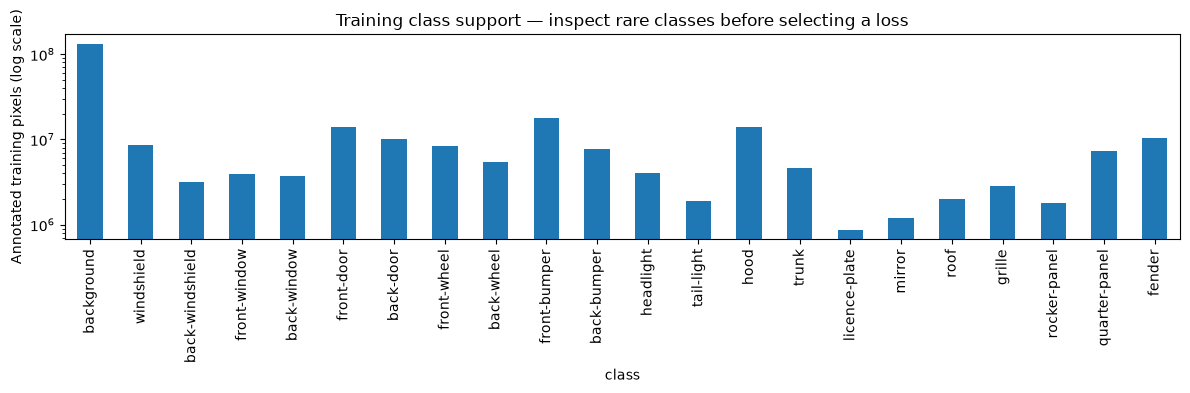

In [5]:
TASK = 'parts'
class_names = manifest["class_names"][TASK]
records = [r for r in manifest["records"] if r["task"] == TASK]
assert len(class_names) == 22, f"Unexpected taxonomy: {class_names}"
assert class_names[0] == "background"
print("Class IDs:", dict(enumerate(class_names)))
display(pd.DataFrame(sorted(Counter(r["split"] for r in records).items()),
                     columns=["partition", "images"]))

# Show training pixel support only; validation and final reports report their own support.
train_records = [r for r in records if r["split"] == "train"]
assert train_records, "No training samples: inspect conversion/split reports."
pixel_counts = np.zeros(len(class_names), dtype=np.int64)
for record in train_records:
    with Image.open(record["mask_path"]) as im:
        labels = np.asarray(im)
        pixel_counts += np.bincount(labels[labels < len(class_names)].ravel(),
                                    minlength=len(class_names))
support = pd.DataFrame({"class": class_names, "training_pixels": pixel_counts})
display(support)
ax = support.set_index("class")["training_pixels"].plot.bar(figsize=(12, 4), logy=True)
ax.set_ylabel("Annotated training pixels (log scale)")
ax.set_title("Training class support — inspect rare classes before selecting a loss")
plt.tight_layout()


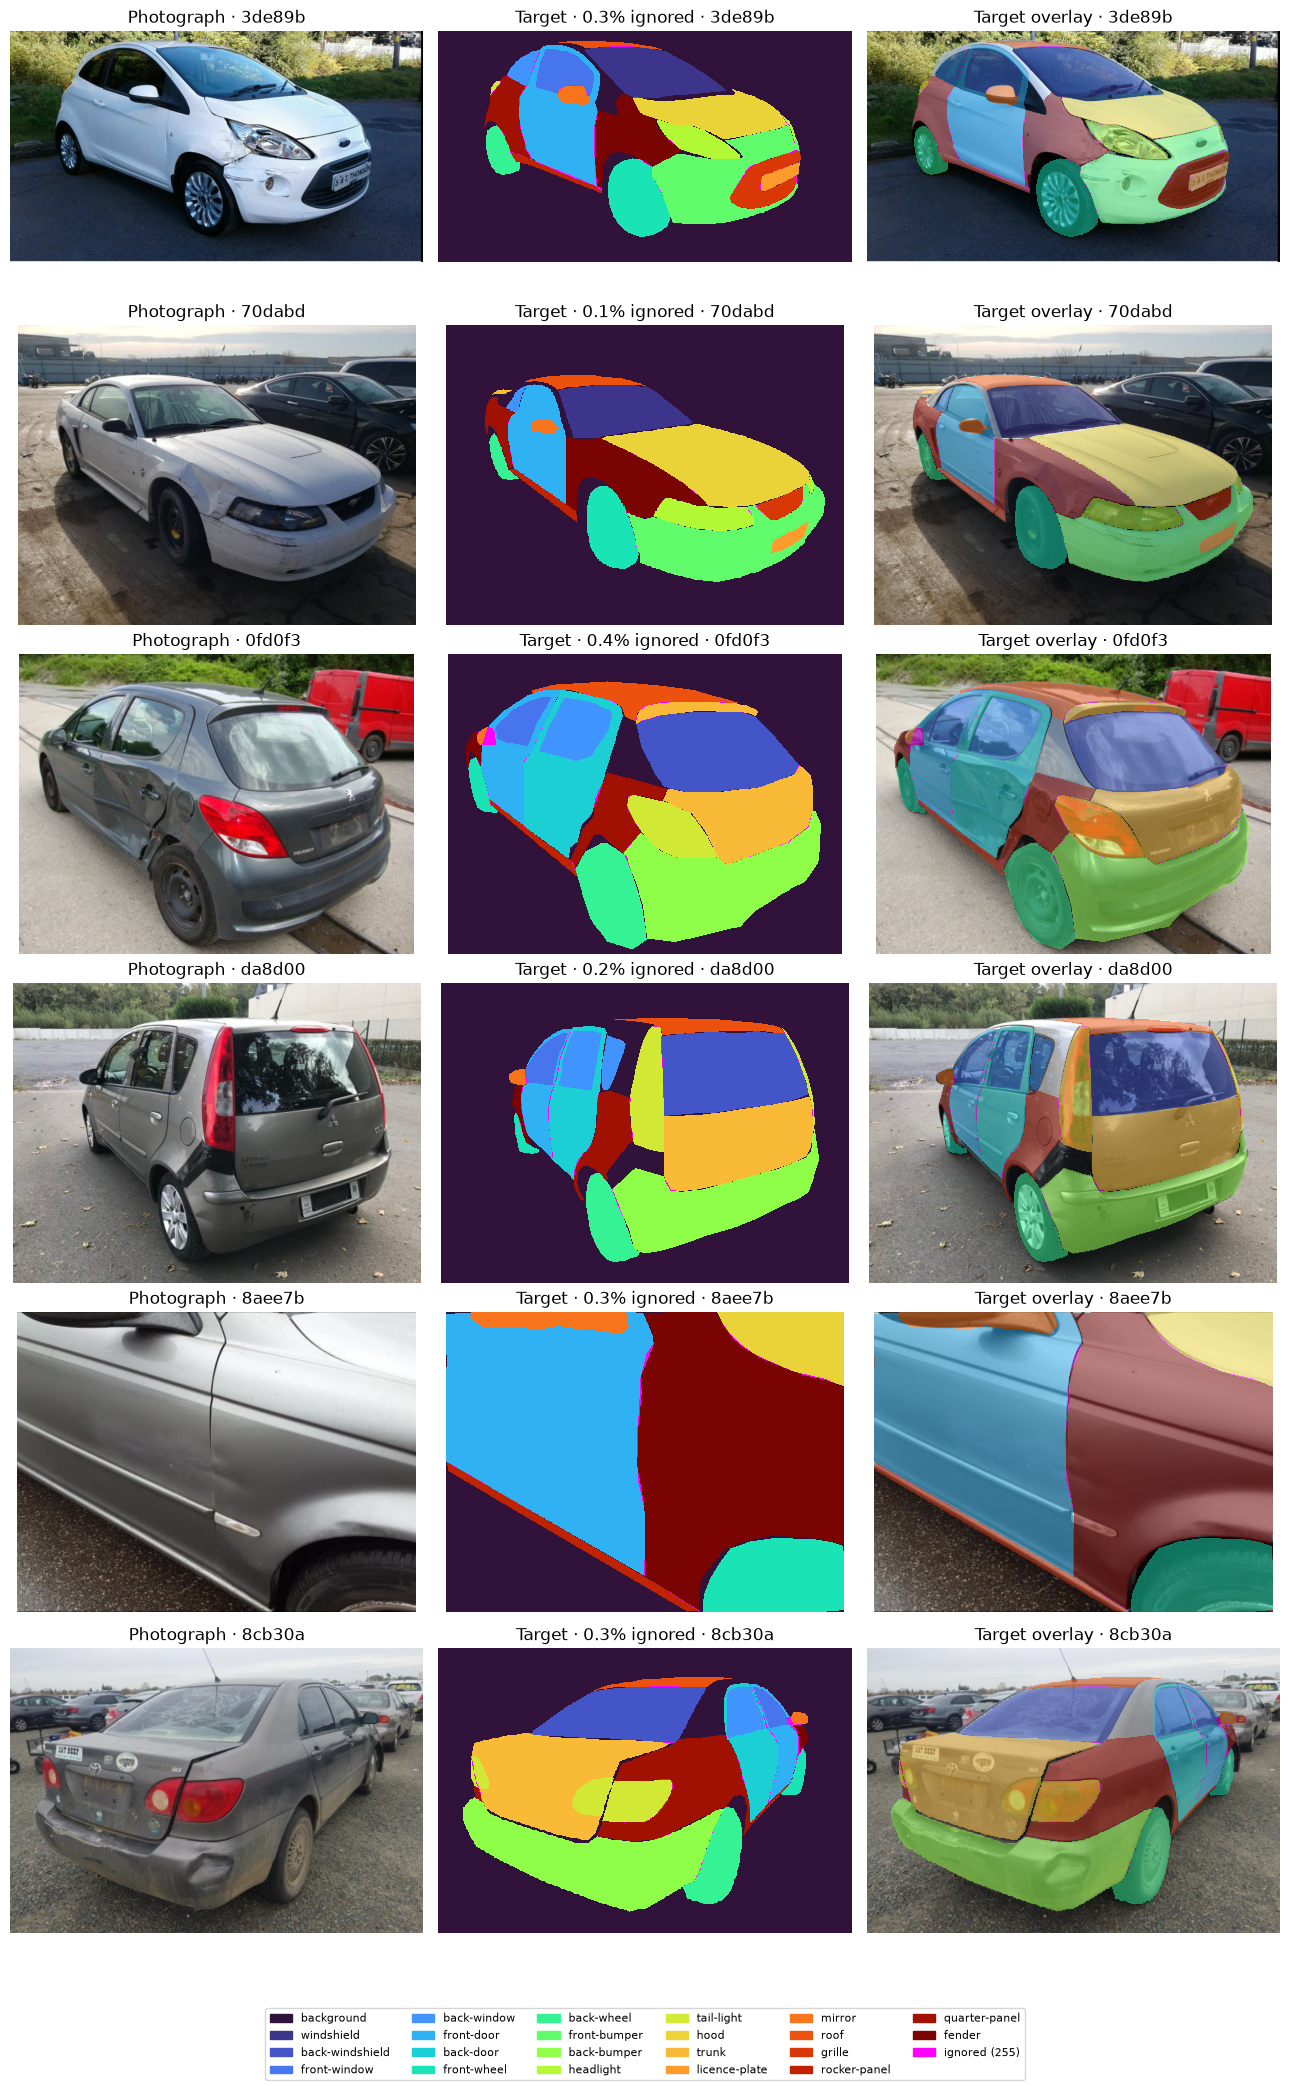

In [6]:
# Visual audit before training: TRAINING images containing the rarest classes, plus random ones.
# Magenta marks ignored pixels (255). Change seed to see other examples.
show_targets(manifest, TASK, split="train", count=6, seed=0)
plt.show()


## Encoder, segmentation head and backbone alternatives

The default checkpoint is [`nvidia/mit-b2`](https://huggingface.co/nvidia/mit-b2): an ImageNet-pretrained **Mix Transformer B2 encoder**, not already HITL-trained weights. The four hierarchical encoder stages retain pretrained weights and are fine-tuned. A new SegFormer all-MLP decoder projects features from each stage to a shared channel width, upsamples them to a common resolution, concatenates and fuses them, then applies normalization/activation/dropout and a final **1×1 classifier producing 22 logits per spatial location**. Bilinear upsampling aligns logits with the target image grid. Argmax yields the semantic mask; softmax gives pixel-class probabilities. There is no additional whole-image classification branch.

`freeze_encoder_epochs=0` fine-tunes all encoder layers from the start. Set it to a small positive number to warm up the new head first. Encoder learning rate is lower than the head learning rate. With `lr_schedule="poly"` or `"cosine"`, both rates rise linearly during `warmup_epochs` and then decay after every optimizer update; `"cosine_epoch"` is the original once-per-epoch schedule without warmup. Cross-entropy ignores padding; an optional soft Dice term emphasizes foreground overlap. Compare loss choices using validation only.

| `architecture` | Encoder and added/changed layers | `checkpoint` setting |
| --- | --- | --- |
| `segformer` | Pretrained MiT encoder; new SegFormer decoder and 22-class classifier | `nvidia/mit-b2` default; e.g. `nvidia/mit-b0`, `nvidia/mit-b3` for another scale |
| `resnet50` | ImageNet-pretrained ResNet-50 features with DeepLabV3 atrous spatial pyramid pooling and a new 22-class segmentation classifier | Ignored; torchvision's selected pretrained encoder weights are recorded |
| `resnet101` | Same DeepLabV3 task head with deeper ResNet-101 features | Ignored; torchvision's selected pretrained encoder weights are recorded |
| `hf_semantic` | A supported Hugging Face semantic segmentation model with its existing decoder and a resized task classifier | Supply a compatible semantic segmentation checkpoint; a classifier-only ViT needs an explicit decoder adapter and is not accepted automatically |

Change the two configuration fields to switch model families. Use the same data version, taxonomy, input size, normalization policy, seed and evaluation protocol when isolating the effect of the architecture; report deviations and compute budget. Record the exact downloaded revision and licence with the run; `revision` can pin an HF commit. Check checkpoint-specific input/normalization constraints for another ViT. These notebook defaults do not imply every third-party architecture has been exercised.


In [ ]:
# Recipe presets. Change one factor at a time and compare runs on validation only.
#   baseline  - first v1 run: low learning rates, per-epoch cosine, 30 epochs, flip + brightness/contrast
#   fixed     - 10x learning rates, 2-epoch warmup, per-update poly decay, 100 epochs, patience 15
#   fixed_aug - fixed + random scale (0.5-2x) and crop, rotation up to 10 degrees, saturation jitter
RECIPE = "fixed_aug"
RECIPES = {
    "baseline": dict(encoder_lr=6e-6, head_lr=6e-5, lr_schedule="cosine_epoch", warmup_epochs=0,
                     epochs=30, patience=8),
    "fixed": dict(encoder_lr=6e-5, head_lr=6e-4, lr_schedule="poly", warmup_epochs=2,
                  epochs=100, patience=15),
}
RECIPES["fixed_aug"] = {**RECIPES["fixed"], "scale_range": (0.5, 2.0), "rotation_degrees": 10, "saturation": 0.15}

# Main editable experiment configuration. Re-run this cell after any deliberate change.
cfg = TrainingConfig(
    task=TASK,
    architecture="segformer",  # "segformer", "resnet50", "resnet101", "hf_semantic"
    checkpoint="nvidia/mit-b2",  # HF identifier; ignored for torchvision ResNets
    revision=None,  # Pin a Hugging Face checkpoint commit for a frozen experiment.
    pretrained=True,
    image_size=512,  # Try 384 to reduce memory; compare 640 if small details vanish.
    batch_size=2,
    accumulation_steps=4,  # Effective batch ~= 8; final partial accumulation is handled.
    weight_decay=0.01,
    freeze_encoder_epochs=0,
    ce_weight=1.0,
    dice_weight=0.0,
    horizontal_flip=0.5,
    brightness=0.15,
    contrast=0.15,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
    frame="serving",  # The M1 worker's frame, needed to export a run. "centred" is the frame of earlier runs.
    freeze_batchnorm=True,  # Stable DeepLab operation with small batches.
    device=DEVICE,
    amp=True,  # Harness enables mixed precision on CUDA; MPS/CPU use float32.
    workers=0,  # Portable notebook default, especially on macOS/Windows.
    seed=SPLIT_SEED,
    artifacts_root=str(ROOT / "artifacts"),
    run_id=None,  # Auto-generate a unique run; explicit existing IDs are rejected.
    **RECIPES[RECIPE],
)
print("Recipe:", RECIPE)
print(json.dumps(asdict(cfg), indent=2))
print("Expected model parent:", ROOT / "artifacts/models/parts")


## Inspect the model architecture

The next cell builds the configured model once, on the CPU, so you can see it before training. The table lists modules down to `SUMMARY_DEPTH` levels with their parameter counts, and marks whether it belongs to the pretrained encoder or the newly initialised decoder/head. A test pass with a blank image confirms the model returns one score per class for every input pixel. Set `PRINT_FULL_ARCHITECTURE = True` to print the complete PyTorch module tree (several hundred lines for SegFormer).

Building the model loads the pretrained weights, which downloads them on first use. This preview copy is discarded; the training cell builds its own.


In [8]:
# Build the configured model once on the CPU to inspect it. Training builds its own copy.
PRINT_FULL_ARCHITECTURE = False  # True prints every layer
SUMMARY_DEPTH = 4  # 4 shows SegFormer's four encoder stages; lower it for ResNet backbones
preview_model = build_model(cfg, class_names).eval()
display(model_summary(preview_model, depth=SUMMARY_DEPTH))
encoder_total = sum(p.numel() for p in preview_model.encoder_parameters())
head_total = sum(p.numel() for p in preview_model.head_parameters())
print(f"Encoder parameters: {encoder_total:,} | head/decoder: {head_total:,} | total: {encoder_total + head_total:,}")
with torch.inference_mode():
    blank = torch.zeros(1, 3, cfg.image_size, cfg.image_size)
    print("Input", tuple(blank.shape), "-> logits", tuple(preview_model(blank).shape),
          f"= one score per class ({len(class_names)}) per pixel")
if PRINT_FULL_ARCHITECTURE:
    print(preview_model.network)
del preview_model, blank


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,module,type,level,parameters,part
0,segformer,SegformerModel,1,24196288,encoder
1,segformer.encoder,SegformerEncoder,2,24196288,encoder
2,segformer.encoder.patch_embeddings,ModuleList,3,1929408,encoder
3,segformer.encoder.patch_embeddings.0,SegformerOverlapPatchEmbeddings,4,9600,encoder
4,segformer.encoder.patch_embeddings.1,SegformerOverlapPatchEmbeddings,4,74112,encoder
5,segformer.encoder.patch_embeddings.2,SegformerOverlapPatchEmbeddings,4,369600,encoder
6,segformer.encoder.patch_embeddings.3,SegformerOverlapPatchEmbeddings,4,1476096,encoder
7,segformer.encoder.block,ModuleList,3,22264832,encoder
8,segformer.encoder.block.0,ModuleList,4,944640,encoder
9,segformer.encoder.block.1,ModuleList,4,1863680,encoder


Encoder parameters: 24,196,288 | head/decoder: 3,167,254 | total: 27,363,542
Input (1, 3, 512, 512) -> logits (1, 22, 512, 512) = one score per class (22) per pixel


## Run training manually

Execute the next cell when the data audit and configuration are ready. It loads the pretrained checkpoint (a network download on first use), creates a unique run, and records config, class mapping, split/source fingerprints, environment, hardware, checkpoints and validation history. The training loop evaluates validation only, selects `best.pt` by foreground mIoU, and retains `last.pt` as well. The `fixed` presets run up to 100 epochs; the first M1 run took about 107 seconds per 512-pixel epoch on an Apple-silicon GPU.

`auto` selects CUDA first, then Apple MPS, then CPU. Keep `workers=0` for portable notebook execution. If the model exceeds memory, reduce batch size or image size and increase accumulation if useful; record a new run. For an unsupported MPS operation, explicitly select `device="cpu"` or use a compatible PyTorch build and record that hardware change. The harness does not hide an accelerator failure as a successful GPU run.

Each execution starts a **new training run**. Optimizer/scheduler state is retained in checkpoint artifacts, but automatic interrupted-run resume is not provided by this notebook. The reload cell below supports evaluating a saved run without retraining. Do not call a fresh run an exact continuation of a previous one.


In [9]:
run = train(manifest, cfg)
RUN_DIR = Path(run["run_dir"])
EVALUATION_DIR = Path(run["evaluation_dir"])
print("Model and training artifacts:", RUN_DIR)
print("Evaluation artifacts:", EVALUATION_DIR)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b2 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1/100: train loss 1.8505, val loss 0.7090, val foreground mIoU 0.3456
epoch 2/100: train loss 0.7261, val loss 0.4592, val foreground mIoU 0.5124
epoch 3/100: train loss 0.5390, val loss 0.4013, val foreground mIoU 0.5726
epoch 4/100: train loss 0.4258, val loss 0.3695, val foreground mIoU 0.5942
epoch 5/100: train loss 0.3817, val loss 0.3137, val foreground mIoU 0.6646
epoch 6/100: train loss 0.3318, val loss 0.3142, val foreground mIoU 0.6741
epoch 7/100: train loss 0.3070, val loss 0.2834, val foreground mIoU 0.6857
epoch 8/100: train loss 0.2867, val loss 0.2702, val foreground mIoU 0.6999
epoch 9/100: train loss 0.2601, val loss 0.2537, val foreground mIoU 0.7162
epoch 10/100: train loss 0.2497, val loss 0.2683, val foreground mIoU 0.7040
epoch 11/100: train loss 0.2427, val loss 0.2585, val foreground mIoU 0.7264
epoch 12/100: train loss 0.2272, val loss 0.2398, val foreground mIoU 0.7255
epoch 13/100: train loss 0.2081, val loss 0.2906, val foreground mIoU 0.7183
epoch 14

## Validation metrics and performance plots

Training/validation losses and validation foreground mIoU help reveal underfitting and overfitting. Validation evaluation reloads the **best** checkpoint, so it also checks that the saved weights are usable. Report every class with ground-truth pixel support, IoU, Dice/F1, precision and recall; absent/undefined classes must remain explicit rather than being presented as perfect. Foreground mIoU excludes background; pixel accuracy alone can be misleading when background dominates.

The confusion matrix is a **pixel confusion matrix**, with rows as true classes and columns as predictions. Row normalization highlights which classes are confused even when class support differs. It is not a damage-instance matrix. Overlays should be reviewed alongside numerical metrics for small objects, boundaries, rare labels and misleading background predictions.


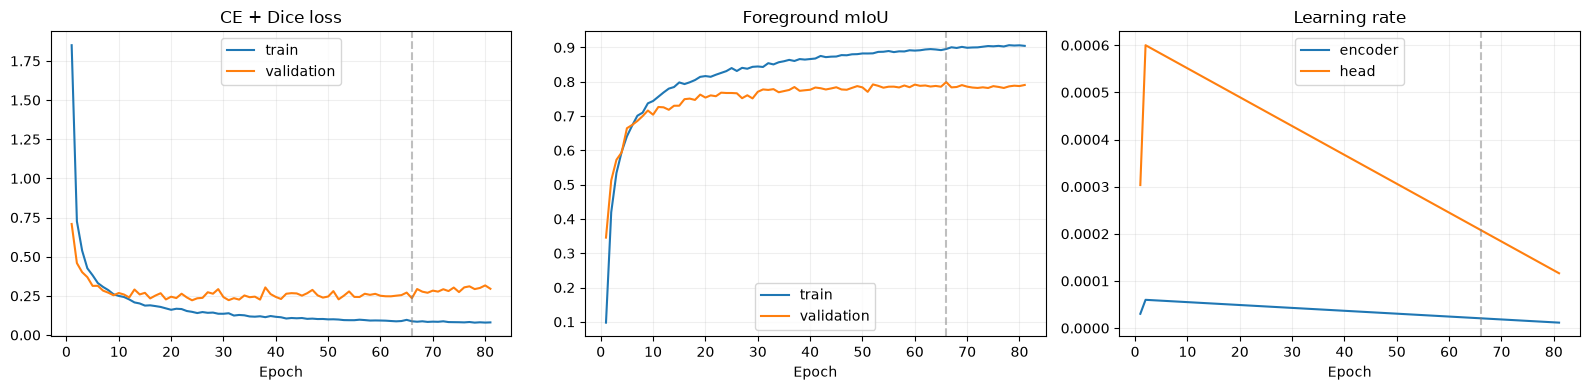

{'miou_foreground': 0.7989103647308896,
 'dice_foreground': 0.8844472740884997,
 'precision_foreground': 0.8843992091654769,
 'recall_foreground': 0.8859820182339206,
 'pixel_accuracy': 0.9454279664177047,
 'valid_pixels': 26750405,
 'macro_class_count': 21,
 'macro_policy': 'background excluded; zero-union classes undefined/excluded; false-positive-only classes included',
 'loss': 0.23520390760330928,
 'image_count': 147,
 'elapsed_seconds': 5.979212999984156,
 'images_per_second': 24.585175340030457,
 'timing_scope': 'full evaluation including loading, loss and CPU confusion',
 'split': 'val',
 'epoch': 66,
 'run_id': 'parts-segformer-20260930T161904Z-f9be9131',
 'checkpoint_sha256': 'bc05be689340588ef616d2b7d7f708c940da582cede0072554df718ba4778d72'}

,class_id,class_name,iou,dice,precision,recall,support_pixels,predicted_pixels,iou_reason
0,0,background,0.955953,0.977481,0.980957,0.974029,13898766,13800615,None
1,1,windshield,0.928721,0.963044,0.962227,0.963862,772539,773852,None
2,2,back-windshield,0.832365,0.908514,0.858037,0.965302,358004,402759,None
3,3,front-window,0.840069,0.913084,0.895024,0.931888,357164,371875,None
4,4,back-window,0.742018,0.851906,0.876785,0.828401,362752,342734,None
5,5,front-door,0.864289,0.927205,0.927132,0.927277,1522412,1522650,None
6,6,back-door,0.787098,0.880867,0.884852,0.876919,760343,753526,None
7,7,front-wheel,0.911302,0.953593,0.945985,0.961325,671875,682770,None
8,8,back-wheel,0.915132,0.955686,0.954997,0.956375,522839,523593,None
9,9,front-bumper,0.868793,0.929790,0.920133,0.939653,1580262,1613787,None


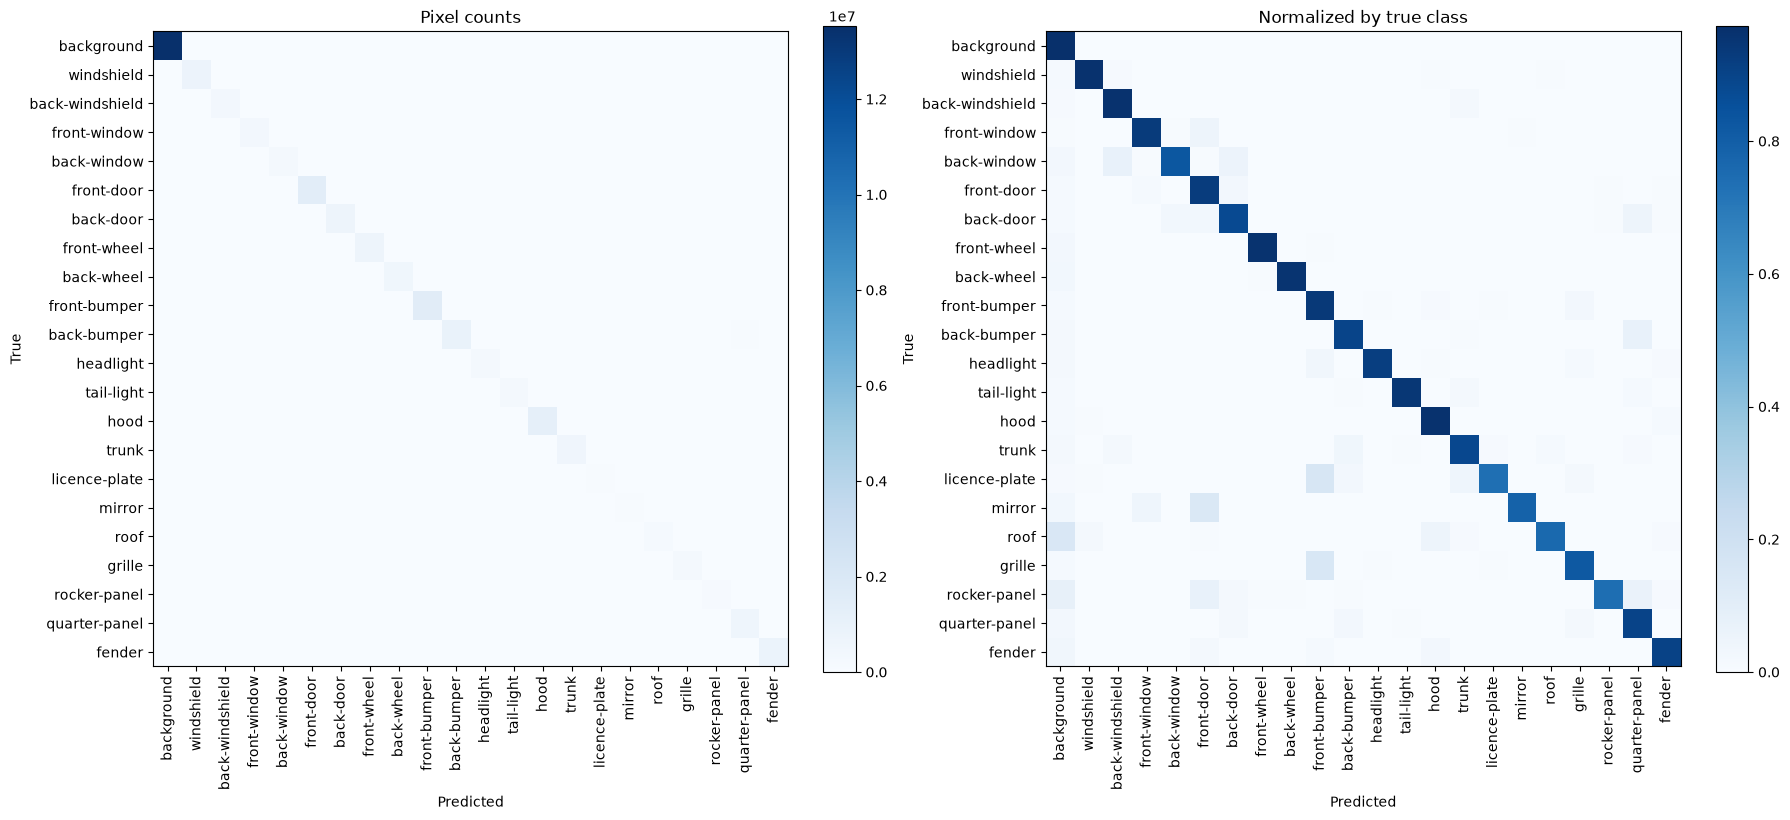

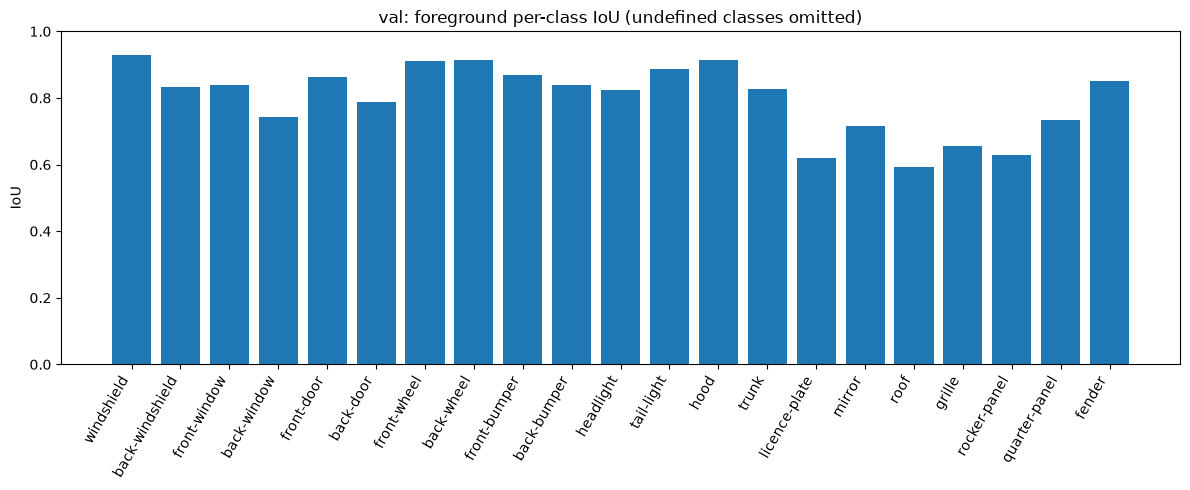

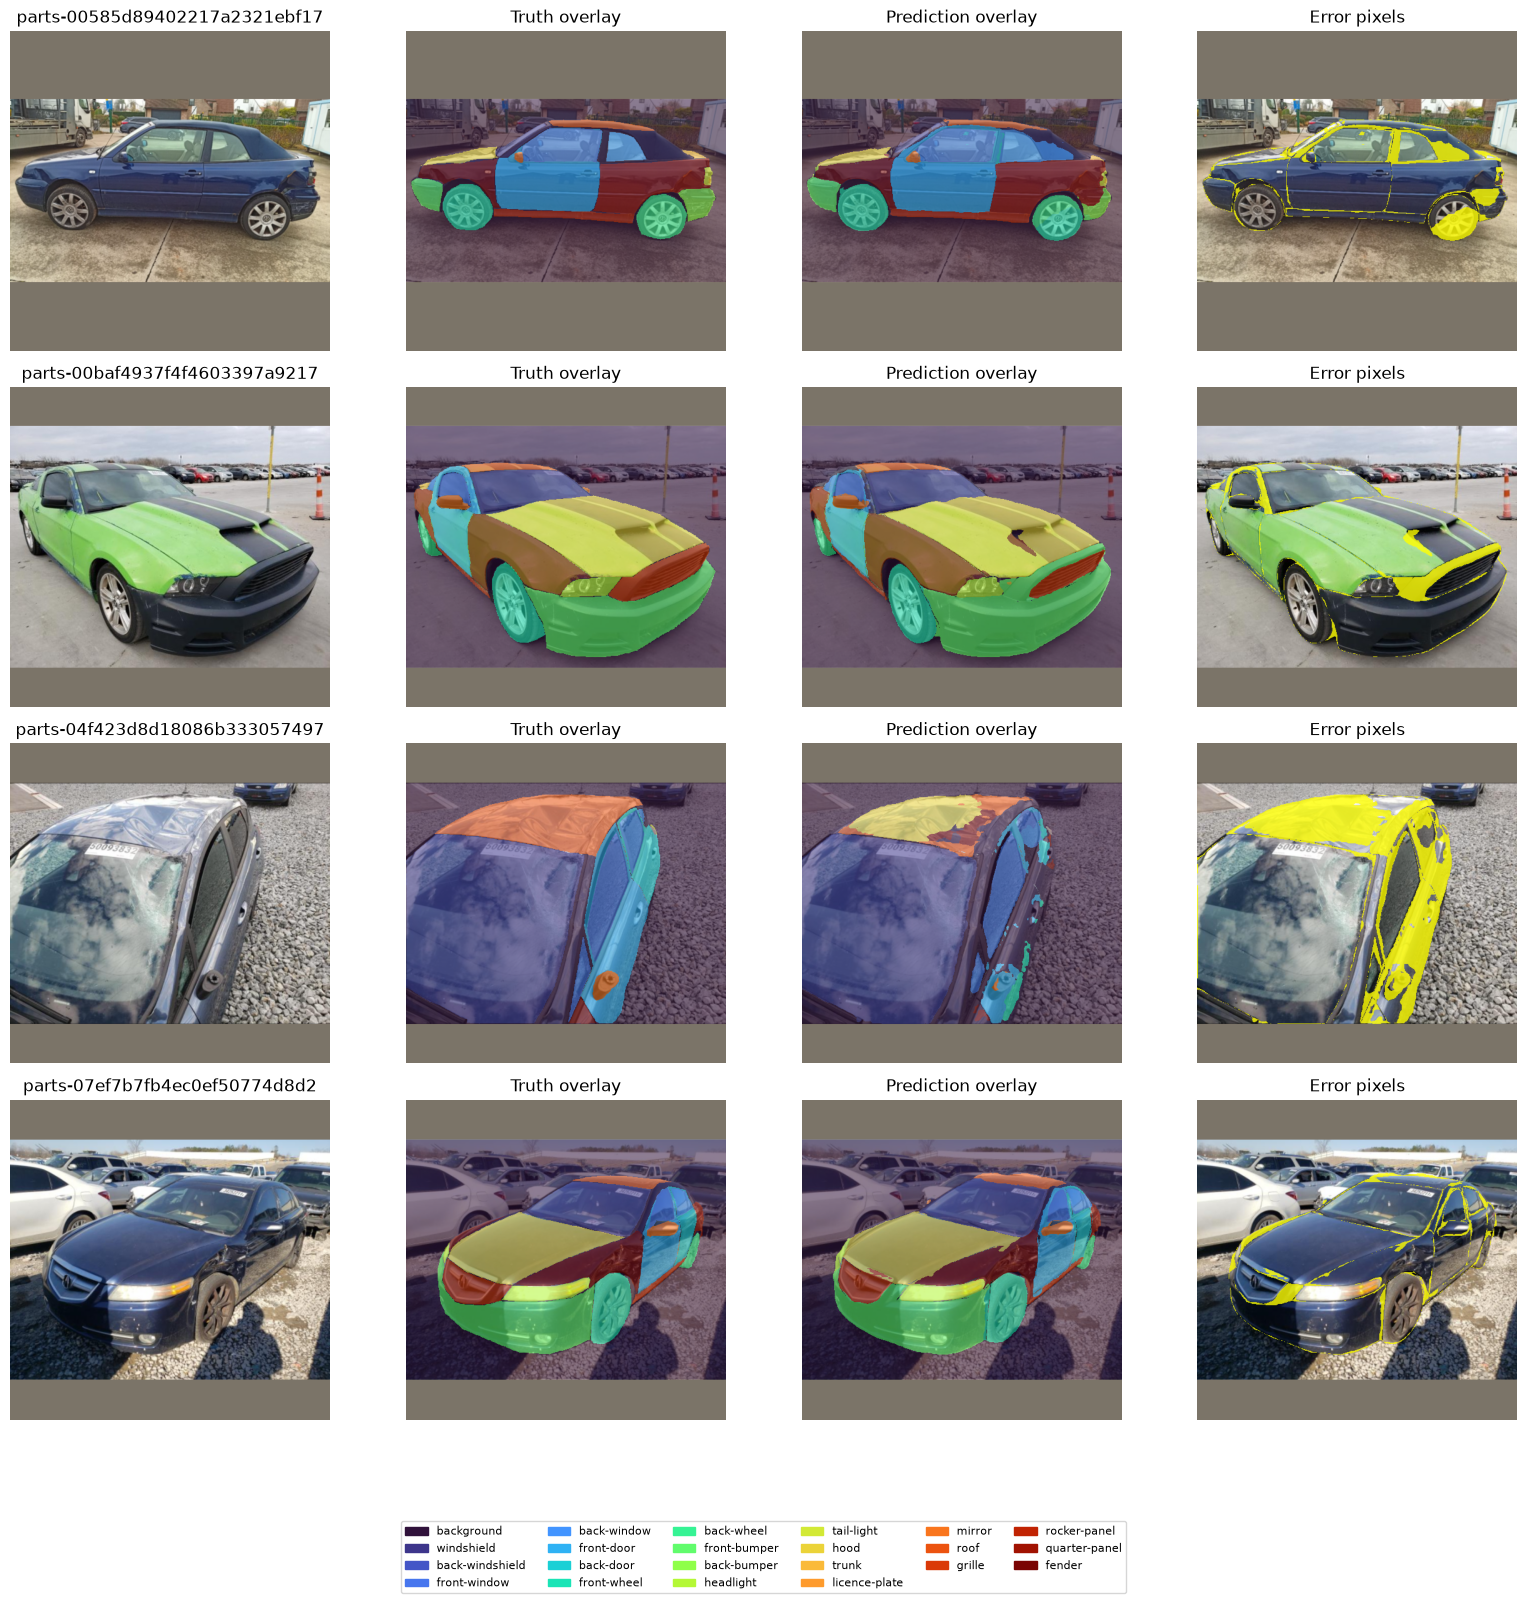

In [10]:
plot_history(RUN_DIR)
plt.show()
validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
display({k: v for k, v in validation_report.items()
         if k not in {"per_class", "confusion_matrix"}})
display(pd.DataFrame(validation_report["per_class"]))
plot_confusion(RUN_DIR, split="val")
plt.show()
show_predictions(RUN_DIR, manifest, split="val", count=4, device=DEVICE)
plt.show()


## Compare manual runs on the same frozen split

Run another architecture by editing the configuration and running the training cell, then list its path here. Compare **validation** metrics while selecting models. The comparison helper checks the shared manifest identity, taxonomy and evaluation resolution, so M1 and M2 are compared separately, and runs on the v1 and v2 preparations (different labels) are refused and different-resolution runs require a separately declared comparison. Keep input size, split, seed and training budget fixed for a controlled architecture comparison; record any deliberate difference. After choosing a model, repeat with additional fixed seeds to estimate variability when the compute budget permits. Validation rankings are development evidence, not final held-out accuracy.


In [11]:
RUNS_TO_COMPARE = [str(RUN_DIR)]
# Add paths from earlier runs of this SAME task/data version, for example:
# RUNS_TO_COMPARE += [str(ROOT / "artifacts/models/parts/<another-run-id>")]
comparison = compare_runs(RUNS_TO_COMPARE)
display(comparison)
# Save only when deliberately recording this comparison:
SAVE_COMPARISON = False
if SAVE_COMPARISON:
    comparison.to_csv(EVALUATION_DIR / "manual_validation_comparison.csv", index=False)


,run_id,architecture,checkpoint,seed,best_epoch,val_miou,val_dice,parameters,device
0,parts-segformer-20260930T161904Z-f9be9131,segformer,nvidia/mit-b2,20260922,66,0.79891,0.884447,27363542,mps


## Reload an existing checkpoint without another training run

After a kernel restart, rerun the imports and preparation/configuration cells, set `RELOAD_RUN_DIR` to a saved run below, then run the validation plotting/evaluation cell. Evaluation rebuilds the architecture from its persisted configuration and loads `best.pt`; it checks task/data compatibility. Move the corresponding prepared dataset and manifest with the run when using another machine, and preserve recorded content identities. This is model reload for inference/evaluation, not optimizer resume. A run saved under transformers 4 reloads under transformers 5: `load_run` translates the tensor names. A run is evaluated against the prepared data it was trained on, so for a run saved on v2 set `PREPARED_DIR` to v2 and `SPLIT_FROM = None` first.


In [12]:
RELOAD_RUN_DIR = None  # e.g. ROOT / "artifacts/models/parts/<saved-run-id>"
if RELOAD_RUN_DIR is not None:
    RUN_DIR = Path(RELOAD_RUN_DIR).expanduser().resolve()
    if not (RUN_DIR / "best.pt").is_file():
        raise FileNotFoundError(f"No saved best checkpoint in {RUN_DIR}")
    EVALUATION_DIR = ROOT / "artifacts/evaluation" / RUN_DIR.name
    print("Reload selected:", RUN_DIR)
    reloaded_validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
    display(reloaded_validation_report)


## Final held-out evaluation — explicit opt-in

Leave `FINAL_EVAL=False` throughout development. Set it to `True` only after selecting and freezing the final run using validation, with no pending split/taxonomy edits. Evaluation exports metrics, the confusion matrix and qualitative results under `artifacts/evaluation/<run_id>/`. Test results must not become a feedback loop for architecture or threshold selection. A later design change requires a new declared evaluation protocol, not repeated claims of untouched test performance.


In [13]:
FINAL_EVAL = False
if FINAL_EVAL:
    final_report = evaluate_run(RUN_DIR, manifest, split="test", device=DEVICE)
    display({k: v for k, v in final_report.items()
             if k not in {"per_class", "confusion_matrix"}})
    display(pd.DataFrame(final_report["per_class"]))
    plot_confusion(RUN_DIR, split="test")
    plt.show()
    show_predictions(RUN_DIR, manifest, split="test", count=4, device=DEVICE)
    plt.show()
else:
    print("Final test remains unused. Continue model selection with validation only.")


Final test remains unused. Continue model selection with validation only.


## Export the run for the M1 worker — explicit opt-in

`export_parts_run` writes the best checkpoint of `RUN_DIR` as a registry entry, `artifacts/models/parts/<name>`, in the form the worker reads: Hugging Face weights, `manifest.json` and `preprocessing.json`. It refuses a run that was not trained in the serving frame, on the parts taxonomy, at the size the worker serves. It then loads the entry with the worker's own verification and loader, and checks that the exported weights give the run's logits. An existing entry is never replaced.

The entry is a candidate. Nothing serves it until `configs/models/parts.yaml` names it in `model_version`, with a new `config_version`; that is a team decision. Its recorded score is this run's validation score on `PREPARED_DIR`, which is not comparable with a score measured on other labels or another split.

In [ ]:
EXPORT_FOR_SERVING = False
EXPORT_VERSION = "parts/0.9.0-b2-notebook"  # parts/<name>; must not exist under artifacts/models
if EXPORT_FOR_SERVING:
    from pipelines.vision.registry import export_parts_run
    entry = export_parts_run(RUN_DIR, EXPORT_VERSION)
    print("Registry entry:", entry)
    print(json.dumps(json.loads((entry / "manifest.json").read_text())["metrics"], indent=2))
else:
    print("Nothing exported. The run stays a notebook artifact.")

## Interpretation, artifacts and next steps

For M1, the project target is foreground mIoU ≥ 0.60 and no agreed supported panel class below 0.40. Freeze the supported-panel class list before measurement and report its denominator alongside all 21 part class scores; the harness's all-foreground mean is not automatically the panel-only acceptance statistic. Do not discard a weak or absent class to improve the mean. Side remains unresolved.

Model artifacts are isolated under `artifacts/models/parts/<run_id>/`, and evaluation artifacts under `artifacts/evaluation/<run_id>/`. Keep the dataset/version/config manifest with the checkpoint when copying to another machine. The final evidence package should include best weights, preprocessing and taxonomy, source/split hashes, config and environment, history plots, every class's support/metrics, confusion matrices and sampled prediction overlays. Clear notebook outputs before committing; large generated assets stay ignored.

These notebooks provide trainable semantic segmentation experiments. A completed training cell does not demonstrate calibrated confidence, reliable absence of damage, runtime integration, side identification or required repairs. Production adapters must preserve source coordinates, uncertainty and version references; then be independently integrated and tested.

References: [training specification](../docs/specs/model_training_specification.md), [evaluation plan](../docs/specs/evaluation_plan.md), [M1](../docs/specs/module-01-vehicle-part-segmentation.md), [M2](../docs/specs/module-02-damage-segmentation.md), [dataset acquisition](../docs/dataset-downloads.md), [SegFormer model documentation](https://huggingface.co/docs/transformers/model_doc/segformer), [MiT-B2 model card](https://huggingface.co/nvidia/mit-b2).
